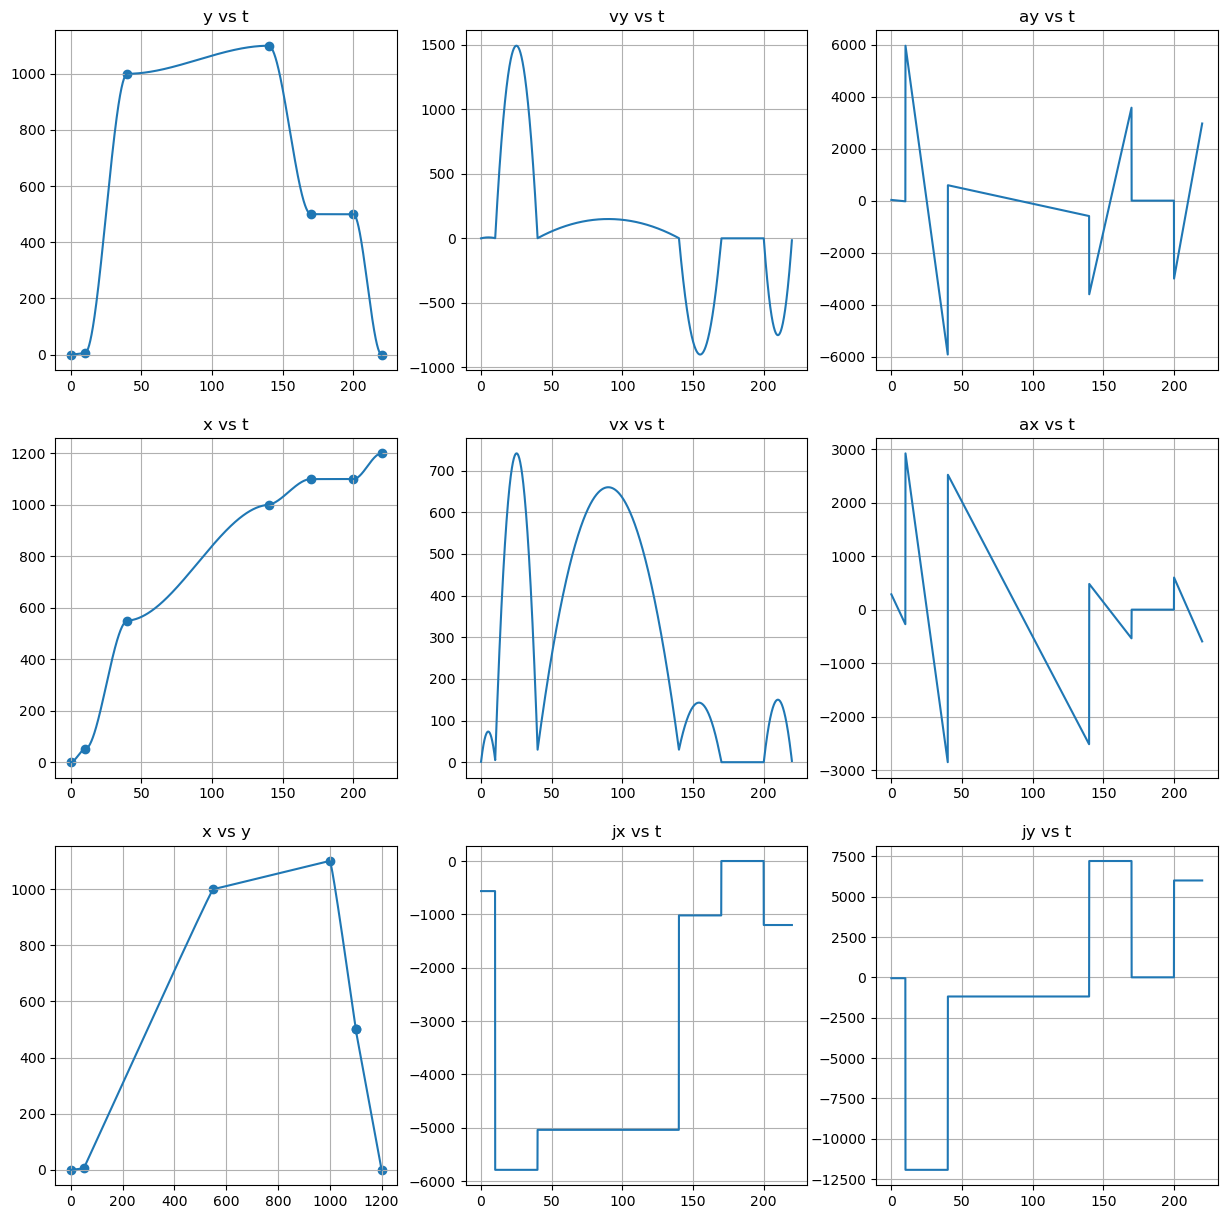

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Scripts.mission_profile import mission_profile

m1 = mission_profile("m1", 1, 1, 0)


m1.add_segment("takeoff",10,50,5,5,1)
m1.add_segment("climb",30,550,1000,30,1)
m1.add_segment("cruise",100,1000,1100,30,1)
m1.add_segment("descent",30,1100,500,0,0)
m1.add_segment("loiter",30,1100,500,0,0)
m1.add_segment("land",20,1200,0,0,0)

list_t = np.arange(0, 220, 0.1)

x = np.zeros(len(list_t))
y = np.zeros(len(list_t))
v_x = np.zeros(len(list_t))
v_y = np.zeros(len(list_t))
a_x = np.zeros(len(list_t))
a_y = np.zeros(len(list_t))
j_x = np.zeros(len(list_t))
j_y = np.zeros(len(list_t))

for i, t in enumerate(list_t):
    x_result, y_result, name = m1.time_solve(t)
    x[i] = x_result[0]
    y[i] = y_result[0]
    v_x[i] = x_result[1]
    v_y[i] = y_result[1]
    a_x[i] = x_result[2]
    a_y[i] = y_result[2]
    j_x[i] = x_result[3]
    j_y[i] = y_result[3]
    

fig, axs = plt.subplots(3, 3)

fig.set_figheight(15)
fig.set_figwidth(15)

axs[0,0].set_title("y vs t")
axs[0,0].plot(list_t, y)
axs[0,0].scatter(m1.t_values,m1.y_coords)
axs[0,0].grid()

axs[1,0].set_title("x vs t")
axs[1,0].plot(list_t, x)
axs[1,0].scatter(m1.t_values,m1.x_coords)
axs[1,0].grid()

axs[2,0].set_title("x vs y")
axs[2,0].plot(x, y)
axs[2,0].scatter(m1.x_coords,m1.y_coords)
axs[2,0].grid()

axs[0,1].set_title("vy vs t")
axs[0,1].plot(list_t, v_y)
axs[0,1].grid()

axs[1,1].set_title("vx vs t")
axs[1,1].plot(list_t, v_x)
axs[1,1].grid()

axs[2,1].set_title("jx vs t")
axs[2,1].plot(list_t, j_x)
axs[2,1].grid()

axs[0,2].set_title("ay vs t")
axs[0,2].plot(list_t, a_y)
axs[0,2].grid()

axs[1,2].set_title("ax vs t")
axs[1,2].plot(list_t, a_x)
axs[1,2].grid()

axs[2,2].set_title("jy vs t")
axs[2,2].plot(list_t, j_y)
axs[2,2].grid()


In [2]:
# Determine masses; moments of inertia; and surface area (for drag)

# Build vehicle coordinate system

# use prop data to determine acceleration; 70% power; 1 dimension 